# Segmenting players with clustering

"Our players" is not one group. Some log in for five minutes on the bus,
some grind for hours, some mainly play with friends, and a few spend
hundreds of dollars. Treating them the same wastes marketing money and
designs features for nobody in particular.

**Clustering** groups players by behaviour without being told what the
groups are. This notebook uses k-means, the most common method, and covers:

1. Preparing the data (the step that decides whether clustering works)
2. Choosing the number of segments
3. Describing each segment in plain terms
4. Checking the result against the truth

The data is simulated from four hidden player types. The algorithm never
sees them; at the end we check whether it found them on its own.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from sample_data import game_player_behaviour

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})
features, hidden_persona = game_player_behaviour()
print(f"{len(features):,} players, 30 days of behaviour each")
features.describe().round(1)

4,000 players, 30 days of behaviour each


,sessions_per_week,avg_session_minutes,spend_30d_usd,pvp_share,friends
count,4000.0,4000.0,4000.0,4000.0,4000.0
mean,6.7,17.8,22.6,0.2,6.9
std,5.2,14.7,120.7,0.2,11.0
min,0.5,1.0,0.0,0.0,0.0
25%,2.8,7.3,0.5,0.1,1.0
50%,4.5,11.9,1.2,0.2,3.0
75%,9.9,25.2,3.3,0.3,6.0
max,32.3,94.0,2913.0,1.0,72.0


## 1. Preparing the data

K-means groups players who are close together, measuring closeness as plain
distance across all columns. Two problems follow from that:

- **Scale:** spend runs into the hundreds while PvP share runs 0 to 1, so
  without rescaling, spend would dominate every distance.
- **Skew:** a handful of big spenders sit far from everyone else. A log
  transform pulls them in so they don't distort the clusters.

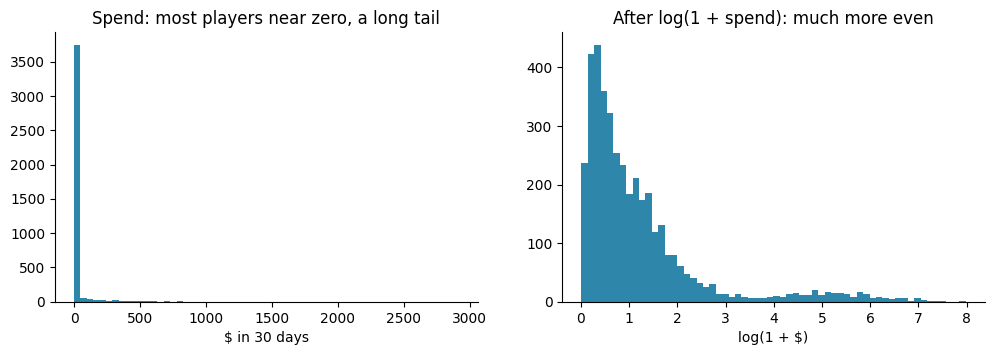

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(features.spend_30d_usd, bins=60, color="#2e86ab")
axes[0].set(title="Spend: most players near zero, a long tail", xlabel="$ in 30 days")
axes[1].hist(np.log1p(features.spend_30d_usd), bins=60, color="#2e86ab")
axes[1].set(title="After log(1 + spend): much more even", xlabel="log(1 + $)");

In [ ]:
prepared = features.copy()
prepared["spend_30d_usd"] = np.log1p(prepared.spend_30d_usd)
prepared["friends"] = np.log1p(prepared.friends)
X = StandardScaler().fit_transform(prepared)

# Same algorithm, raw data vs prepared data, scored against the hidden truth
# (adjusted Rand index: 1 is a perfect match, 0 is no better than random).
raw_labels = KMeans(4, n_init=10, random_state=0).fit_predict(features)
prepared_labels = KMeans(4, n_init=10, random_state=0).fit_predict(X)
print(f"Agreement with the true player types, raw data:      {adjusted_rand_score(hidden_persona, raw_labels):.2f}")
print(f"Agreement with the true player types, prepared data: "
      f"{adjusted_rand_score(hidden_persona, prepared_labels):.2f}")

Agreement with the true player types, raw data:      0.08
Agreement with the true player types, prepared data: 0.86


Same algorithm, same number of clusters, very different result. On raw data,
k-means mostly splits players by how much they spend and ignores everything
else. Preparing the data is not a formality; it's most of the work.

## 2. How many segments?

K-means needs to be told *k*, the number of clusters. Two common guides:

- **Elbow:** total distance from each player to its cluster centre always
  falls as k grows; look for the point where it stops falling quickly.
- **Silhouette score:** how much closer each player is to its own cluster
  than to the next nearest one (higher is better, max 1).

Highest silhouette score at k = 4


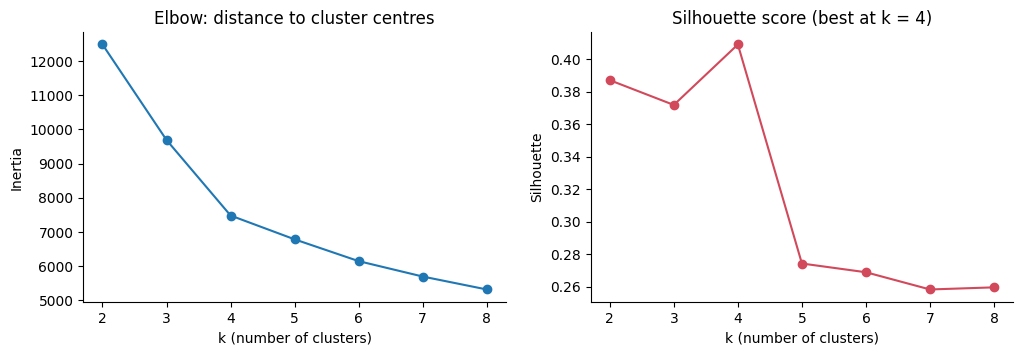

In [ ]:
ks = range(2, 9)
inertia, silhouette = [], []
for k in ks:
    km = KMeans(k, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, km.labels_, sample_size=2000, random_state=0))

best_k = ks[int(np.argmax(silhouette))]
fig, (left, right) = plt.subplots(1, 2, figsize=(12, 3.5))
left.plot(ks, inertia, "o-")
left.set(title="Elbow: distance to cluster centres", xlabel="k (number of clusters)", ylabel="Inertia")
right.plot(ks, silhouette, "o-", color="#d1495b")
right.set(title=f"Silhouette score (best at k = {best_k})", xlabel="k (number of clusters)", ylabel="Silhouette")
print(f"Highest silhouette score at k = {best_k}")

Both point to 4 here: the silhouette peaks there, and the elbow curve bends
there. Real data is rarely this tidy, and the
final choice is partly a business one: four segments a marketing team can
act on beat nine that differ only slightly.

## 3. Describing the segments

A cluster number means nothing to a product manager. Describe each segment
by its typical (median) behaviour, then give it a name a human would use.

In [ ]:
km = KMeans(best_k, n_init=10, random_state=0).fit(X)
segments = features.assign(segment=km.labels_)
profile = segments.groupby("segment").median().round(2)
profile["share_of_players"] = segments.segment.value_counts(normalize=True).sort_index().round(2)
profile["share_of_revenue"] = (segments.groupby("segment").spend_30d_usd.sum() / segments.spend_30d_usd.sum()).round(2)
profile

,sessions_per_week,avg_session_minutes,spend_30d_usd,pvp_share,friends,share_of_players,share_of_revenue
segment,,,,,,,
0,8.01,18.17,2.10,0.17,25.0,0.18,0.03
1,12.94,36.76,3.14,0.32,3.0,0.21,0.05
2,9.91,28.82,173.78,0.55,7.0,0.07,0.90
3,3.02,8.10,0.55,0.10,1.0,0.54,0.02


In [ ]:
def name_segment(row):
    if row.spend_30d_usd > 50:
        return "Big spenders"
    if row.friends > 15:
        return "Social players"
    if row.sessions_per_week > 9:
        return "Grinders"
    return "Casual players"


profile.index = profile.apply(name_segment, axis=1)
profile[["share_of_players", "share_of_revenue", "sessions_per_week", "avg_session_minutes",
         "spend_30d_usd", "pvp_share", "friends"]]

,share_of_players,share_of_revenue,sessions_per_week,avg_session_minutes,spend_30d_usd,pvp_share,friends
Social players,0.18,0.03,8.01,18.17,2.10,0.17,25.0
Grinders,0.21,0.05,12.94,36.76,3.14,0.32,3.0
Big spenders,0.07,0.90,9.91,28.82,173.78,0.55,7.0
Casual players,0.54,0.02,3.02,8.10,0.55,0.10,1.0


Now each segment suggests its own strategy:

- **Casual players** are the biggest group but bring little revenue. Keep
  sessions short and rewarding; ads may suit them better than purchases.
- **Grinders** play the most. They want progression and long-term goals,
  and they're the first to notice when content runs dry.
- **Social players** stay for their friends. Guilds, gifting and co-op modes
  are what keep them.
- **Big spenders** are a small share of players and the majority of revenue.
  They lean towards competitive play, so they care most about fairness and
  status, and losing a few of them shows up immediately in revenue.

The thresholds in `name_segment` come from reading the profile table above.
That's normal: the algorithm finds groups, and a person names them.

## 4. Did it find the real types?

Because we generated the data, we can compare the segments with the hidden
player types. In real life you'd validate differently: check that segments
are stable when you re-run with a different random seed, and that they
behave differently on things the clustering didn't see, like retention.

In [ ]:
labels = pd.Series(profile.index[km.labels_], name="found segment")
print(pd.crosstab(hidden_persona.rename("true type"), labels))
print(f"\nAdjusted Rand index: {adjusted_rand_score(hidden_persona, km.labels_):.2f}")

found segment  Big spenders  Casual players  Grinders  Social players
true type                                                            
casual                    0            2029         0               4
grinder                   9              61       816             100
social                    0              50        18             630
whale                   273               0         9               1

Adjusted Rand index: 0.86


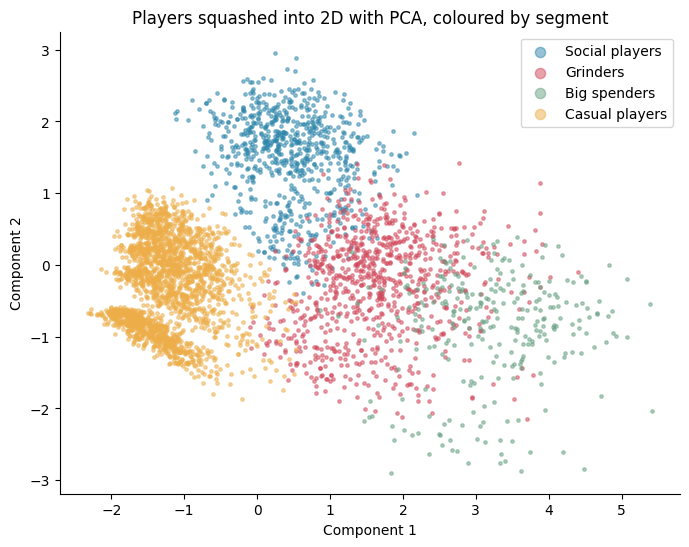

In [ ]:
coords = PCA(2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(8, 6))
for name, color in zip(profile.index, ["#2e86ab", "#d1495b", "#66a182", "#edae49"], strict=True):
    mask = labels == name
    ax.scatter(coords[mask, 0], coords[mask, 1], s=6, alpha=0.5, color=color, label=name)
ax.set(title="Players squashed into 2D with PCA, coloured by segment", xlabel="Component 1", ylabel="Component 2")
ax.legend(markerscale=3);

Most players land in the segment matching their true type. The mistakes
are where types genuinely overlap: a grinder who plays shorter sessions looks
casual, and one with a lot of friends looks social. No algorithm can separate
players who behave the same, and real segments always have blurry edges.
The PCA plot squashes five columns into two so we can see the
groups. It's only a picture: the clustering itself used all five columns.

## Takeaways

- Scale your features and tame skewed ones before clustering; it changes everything.
- Use the elbow and silhouette as guides, then pick a k the business can act on.
- Describe segments with medians and shares of players and revenue, then name them.
- Validate segments on behaviour the algorithm didn't see, and check they're stable.